In [ ]:
import numpy as np
import pandas as pd

import plotly.express as px

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, SGDRegressor

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error



#IMPORT DOS DADOS

In [ ]:
df = pd.read_csv('/content/Student_Performance.csv', sep=',')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


#SIGNIFICADO DOS ATRIBUTOS

ATRIBUTOS PREVISORES

Hours Studied: O número total de horas gastas estudando por cada aluno.

Previous Scores: As pontuações obtidas pelos alunos em testes anteriores

Extracurricular Activities: Se o aluno participa de atividades extracurriculares (Sim ou Não).

Sleep Hours: O número médio de horas de sono que o aluno tinha por dia.

Sample Question Papers Practiced: O número de questionários que o aluno praticou.

VARIAVEL ALVO

Performance Index: Uma medida do desempenho geral de cada aluno. O índice de desempenho representa o desempenho acadêmico do aluno e foi arredondado para o número inteiro mais próximo. O índice varia de 10 a 100, com valores mais elevados indicando melhor desempenho.

#TRATAMENTO DOS DADOS


Verificando se possui valores null

In [ ]:
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [ ]:
df.dtypes

,0
Hours Studied,int64
Previous Scores,int64
Extracurricular Activities,object
Sleep Hours,int64
Sample Question Papers Practiced,int64
Performance Index,float64


In [ ]:
dados = pd.DataFrame.copy(df)

dados['Extracurricular Activities'] = dados['Extracurricular Activities'].map({'Yes': 1, 'No': 0})
dados['Performance Index'] = dados['Performance Index'].astype(int)

display(dados.head())

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91
1,4,82,0,4,2,65
2,8,51,1,7,2,45
3,5,52,1,5,2,36
4,7,75,0,8,5,66


In [ ]:
dados.dtypes

,0
Hours Studied,int64
Previous Scores,int64
Extracurricular Activities,int64
Sleep Hours,int64
Sample Question Papers Practiced,int64
Performance Index,int64


In [ ]:
dados.describe()


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,0.494800,6.530600,4.583300,55.224800
std,2.589309,17.343152,0.499998,1.695863,2.867348,19.212558
min,1.000000,40.000000,0.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,0.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,0.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,1.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,1.000000,9.000000,9.000000,100.000000


#ANALISE DE OUTLIERS

In [ ]:
boxplot = px.box(dados, y="Hours Studied")
boxplot.show()

In [ ]:
boxplot = px.box(dados, y="Previous Scores")
boxplot.show()

In [ ]:
boxplot = px.box(dados, y="Extracurricular Activities")
boxplot.show()

In [ ]:
boxplot = px.box(dados, y="Sleep Hours")
boxplot.show()

In [ ]:
boxplot = px.box(dados, y="Sample Question Papers Practiced")
boxplot.show()

In [ ]:
boxplot = px.box(dados, y="Performance Index")
boxplot.show()

#DESBALANCEAMENTO

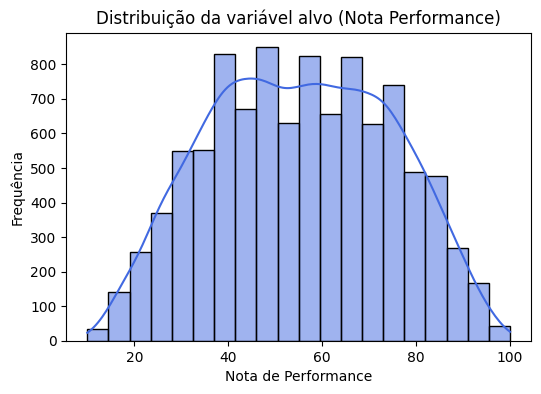

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(dados['Performance Index'], bins=20, kde=True, color='royalblue')
plt.title("Distribuição da variável alvo (Nota Performance)")
plt.xlabel("Nota de Performance")
plt.ylabel("Frequência")
plt.show()


#ANALISE DE CORRELAÇÃO

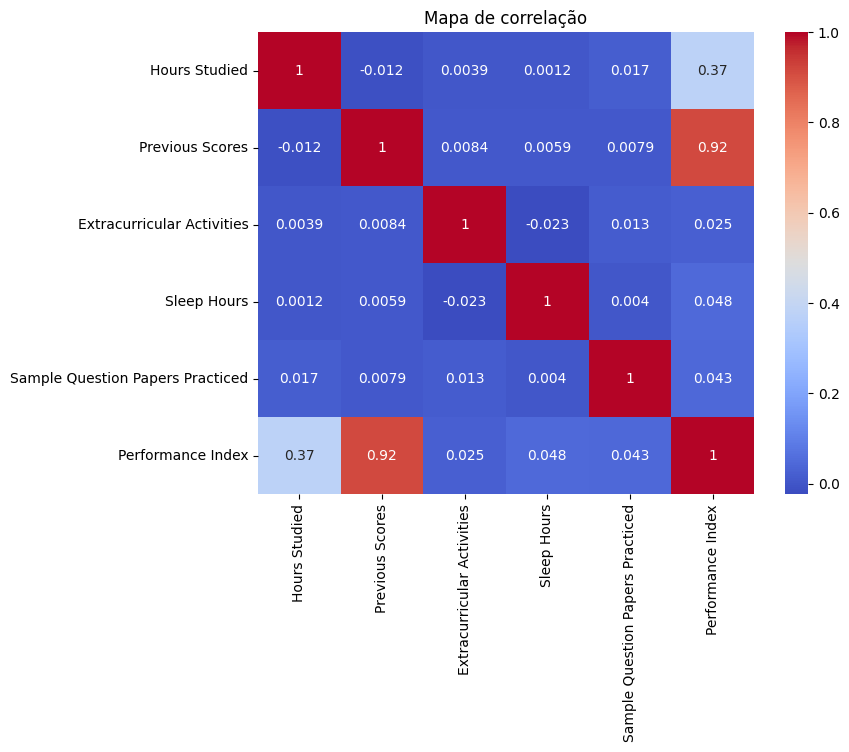

In [ ]:
corr = dados.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Mapa de correlação")
plt.show()


#SEPARAÇÃO DOS DADOS

In [ ]:
dados.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91
1,4,82,0,4,2,65
2,8,51,1,7,2,45
3,5,52,1,5,2,36
4,7,75,0,8,5,66


Separação dos dados = x

In [ ]:
independentes = dados.iloc[:,0:5].values
independentes

array([[ 7, 99,  1,  9,  1],
       [ 4, 82,  0,  4,  2],
       [ 8, 51,  1,  7,  2],
       ...,
       [ 6, 83,  1,  8,  5],
       [ 9, 97,  1,  7,  0],
       [ 7, 74,  0,  8,  1]])

Separação do resultado esperado = Y

In [ ]:
dependente = dados.iloc[:,5].values
dependente

array([91, 65, 45, ..., 74, 95, 64])

#T-SNE

In [ ]:
# Normaliza as variáveis
scaler = StandardScaler()
X_scaled = scaler.fit_transform(independentes)

# Aplica t-SNE para reduzir de 5D -> 2D
tsne = TSNE(n_components=2, perplexity=20, random_state=42)
X_embedded = tsne.fit_transform(X_scaled)

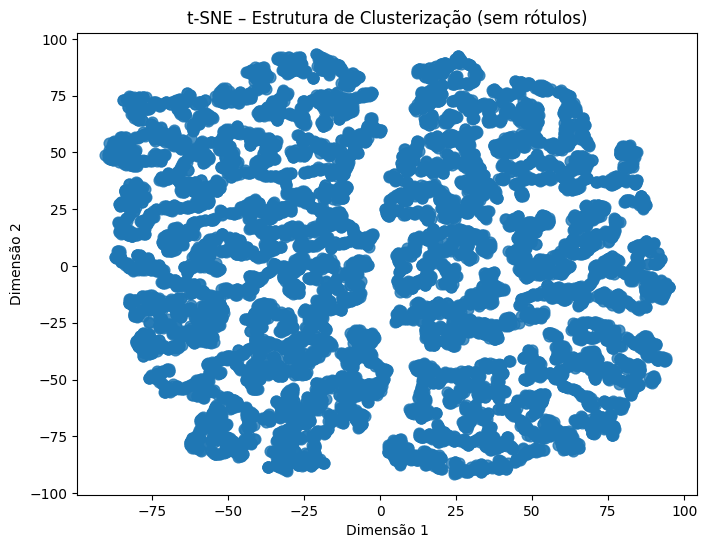

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], s=60, alpha=0.8)
plt.title("t-SNE – Estrutura de Clusterização (sem rótulos)")
plt.xlabel("Dimensão 1")
plt.ylabel("Dimensão 2")
plt.show()


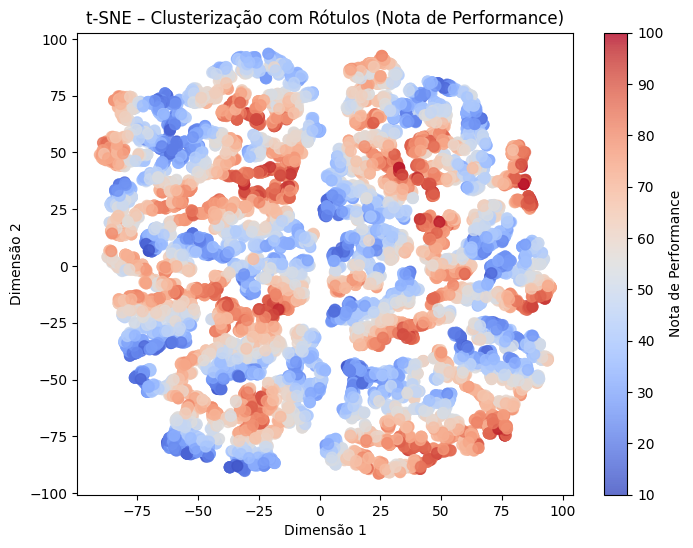

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=dependente, cmap='coolwarm', s=60, alpha=0.8)
plt.title("t-SNE – Clusterização com Rótulos (Nota de Performance)")
plt.xlabel("Dimensão 1")
plt.ylabel("Dimensão 2")
cbar = plt.colorbar()
cbar.set_label("Nota de Performance")
plt.show()


#TREINO

In [ ]:
x_treino, x_teste, y_treino, y_teste = train_test_split(independentes, dependente, test_size = 0.3, random_state = 42)

In [ ]:
x_treino.shape, x_teste.shape , y_treino.shape, y_teste.shape

((7000, 5), (3000, 5), (7000,), (3000,))

In [ ]:
scaler = StandardScaler()
x_treino = scaler.fit_transform(x_treino)
x_teste = scaler.transform(x_teste)

#REGRESSÃO RIDGE

In [ ]:
import numpy as np

class RidgeRegression:
    def __init__(self, alpha=1.0):
        self.alpha = alpha  #parametro de regularização (penalização)
        self.coef_ = None
        self.intercept_ = None
        self.theta = None

    def fit(self, X, y):

        #convertendo entradas para arrays numPy
        X = np.asarray(X)
        y = np.asarray(y)


        # Garante que y seja um vetor coluna
        y = y.reshape(-1, 1)

        # Adiciona o termo de intercepto
        X_b = np.c_[np.ones((X.shape[0], 1)), X]

        # Matriz identidade do tamanho de X_b
        n_features = X_b.shape[1]
        I = np.eye(n_features)

        # Não penalizar o intercepto (primeiro termo)
        I[0, 0] = 0

        # Equação normal com regularização Ridge
        A = X_b.T.dot(X_b) + self.alpha * I
        b = X_b.T.dot(y)
        theta = np.linalg.inv(A).dot(b)

        # Separa intercepto e coeficientes
        self.intercept_ = theta[0, 0]
        self.coef_ = theta[1:,0]

        self.theta = theta
        return self


    def predict(self, X):

        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return X_b.dot(self.theta).flatten()


In [ ]:
regressaoRidge =Ridge()
regressaoRidge.fit(x_treino, y_treino)

regressaoRidgeImplementado = RidgeRegression()
regressaoRidgeImplementado.fit(x_treino, y_treino)

#REGRESSAO GRADIENTE DESCENDENTE

In [ ]:
import numpy as np

class SGDRegression:


    def __init__(self, n_epochs=100, eta0=0.1, t0=5, t1=50, random_state=None):
        self.n_epochs = n_epochs
        self.t0 = t0
        self.t1 = t1
        self.random_state = random_state
        self.eta0 = eta0 #learning rate inicial

        self.theta_ = None
        self.coef_ = None
        self.intercept_ = None

    def _learning_schedule(self, t):
        return self.eta0 * (self.t0 / (t + self.t1))

    def fit(self, X, y):

        if self.random_state is not None:
            np.random.seed(self.random_state)

        # converte para arrays numpy
        X = np.asarray(X)
        y = np.asarray(y)


        # Garante que y seja um vetor coluna
        y = y.reshape(-1, 1)


        m, n = X.shape
        # adiciona o intercepto (coluna de 1s)
        X_b = np.c_[np.ones((X.shape[0], 1)), X]


        # inicialização aleatória dos parâmetros
        self.theta_ = np.random.randn(n + 1, 1)

        t = 0  # contador global de iterações
        for epoch in range(self.n_epochs):
            for i in range(m):

                # seleciona uma instância aleatória do conjunto
                random_index = np.random.randint(m)
                xi = X_b[random_index:random_index+1]
                yi = y[random_index:random_index+1]

                # gradiente derivado do MSE: 2 * xi.T.dot(xi.dot(theta) - yi)
                gradients = 2 * xi.T.dot(xi.dot(self.theta_) - yi)

                # learning rate ajustado
                eta = self._learning_schedule(t)

                # atualização dos parâmetros
                self.theta_ = self.theta_ - eta * gradients
                t += 1

        # separa coeficientes e intercepto
        self.intercept_ = self.theta_[0, 0]
        self.coef_ = self.theta_[1:,0]

        return self

    def predict(self, X):

        X = np.asarray(X)
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return X_b.dot(self.theta_).ravel()



In [ ]:
regressaoGradienteDescendente = SGDRegressor(random_state=42)
regressaoGradienteDescendente.fit(x_treino, y_treino)

regressaoGradienteDescendenteImplementado = SGDRegression(random_state=42)
regressaoGradienteDescendenteImplementado.fit(x_treino, y_treino)


#AVALIAÇÃO R2 E MSE

Valor Teta 0

In [ ]:
intercept_df = pd.DataFrame({
    'Model': ['Ridge', 'Ridge (Implemented)', 'SGD', 'SGD (Implemented)'],
    'Intercept': [regressaoRidge.intercept_, regressaoRidgeImplementado.intercept_, regressaoGradienteDescendente.intercept_[0], regressaoGradienteDescendenteImplementado.intercept_]
})

display(intercept_df)

,Model,Intercept
0,Ridge,55.399714
1,Ridge (Implemented),55.399714
2,SGD,55.380978
3,SGD (Implemented),55.395984


Valor dos tetas 1,2,3,4,5

In [ ]:
coef_df = pd.DataFrame({
    'Model': ['Ridge', 'Ridge (Implementado)', 'SGD', 'SGD (Implementado)'],
    'Coefficients': [regressaoRidge.coef_, regressaoRidgeImplementado.coef_, regressaoGradienteDescendente.coef_, regressaoGradienteDescendenteImplementado.coef_]
})

coef_df['Coefficients'] = coef_df['Coefficients'].apply(lambda x: [f'{i:.5f}' for i in x])

display(coef_df)

,Model,Coefficients
0,Ridge,"[7.42169, 17.60575, 0.29078, 0.81377, 0.54594]"
1,Ridge (Implementado),"[7.42169, 17.60575, 0.29078, 0.81377, 0.54594]"
2,SGD,"[7.38359, 17.59376, 0.27162, 0.81406, 0.54410]"
3,SGD (Implementado),"[7.42396, 17.60758, 0.28780, 0.81366, 0.54446]"


In [ ]:
dados.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91
1,4,82,0,4,2,65
2,8,51,1,7,2,45
3,5,52,1,5,2,36
4,7,75,0,8,5,66


PREDIÇOES


In [ ]:
ridgePredictTreino = regressaoRidge.predict(x_treino)
ridgePredictTeste = regressaoRidge.predict(x_teste)

ridgeImplementadoPredictTreino = regressaoRidgeImplementado.predict(x_treino)
ridgeImplementadoPredictTeste = regressaoRidgeImplementado.predict(x_teste)

gradientePredictTreino = regressaoGradienteDescendente.predict(x_treino)
gradientePredictTeste = regressaoGradienteDescendente.predict(x_teste)

gradienteImplementadoPredictTreino = regressaoGradienteDescendenteImplementado.predict(x_treino)
gradienteImplementadoPredictTeste = regressaoGradienteDescendenteImplementado.predict(x_teste)

In [ ]:
ridge_predictions_df = pd.DataFrame({
    #'Ridge (Treino)': ridgePredictTreino,
    'Ridge (Teste)': ridgePredictTeste,
    #'Ridge Implementado (Treino)': ridgeImplementadoPredictTreino,
    'Ridge Implementado (Teste)': ridgeImplementadoPredictTeste
})

gradiente_predictions_df = pd.DataFrame({
    #'Gradiente Descendente (Treino)': gradientePredictTreino,
    'Gradiente Descendente (Teste)': gradientePredictTeste,
    #'Gradiente Descendente Implementado (Treino)': gradienteImplementadoPredictTreino,
    'Gradiente Descendente Implementado (Teste)': gradienteImplementadoPredictTeste
})

print("Ridge:")
display(ridge_predictions_df.head())

print("\nGradiente:")
display(gradiente_predictions_df.head())

Ridge:


,Ridge (Teste),Ridge Implementado (Teste)
0,54.747343,54.747343
1,22.623598,22.623598
2,47.937738,47.937738
3,31.343583,31.343583
4,43.061466,43.061466



Gradiente:


,Gradiente Descendente (Teste),Gradiente Descendente Implementado (Teste)
0,54.749517,54.747735
1,22.642843,22.610148
2,47.879138,47.931070
3,31.309512,31.334491
4,43.042105,43.060118


R2 e MSE RIDGE

In [ ]:
r2_treinoR = r2_score(y_treino, ridgePredictTreino)
r2_testeR = r2_score(y_teste, ridgePredictTeste)
r2_treino_implementadoR = r2_score(y_treino, ridgeImplementadoPredictTreino)
r2_teste_implementadoR = r2_score(y_teste, ridgeImplementadoPredictTeste)

mse_treinoR = mean_squared_error(y_treino, ridgePredictTreino)
mse_testeR = mean_squared_error(y_teste, ridgePredictTeste)
mse_treino_implementadoR = mean_squared_error(y_treino, ridgeImplementadoPredictTreino)
mse_teste_implementadoR = mean_squared_error(y_teste, ridgeImplementadoPredictTeste)

R2 e MSE GRADIENTE


In [ ]:
r2_treinoG = r2_score(y_treino, gradientePredictTreino)
r2_testeG = r2_score(y_teste, gradientePredictTeste)
r2_treino_implementadoG = r2_score(y_treino, gradienteImplementadoPredictTreino)
r2_teste_implementadoG = r2_score(y_teste, gradienteImplementadoPredictTeste)

mse_treinoG = mean_squared_error(y_treino, gradientePredictTreino)
mse_testeG = mean_squared_error(y_teste, gradientePredictTeste)
mse_treino_implementadoG = mean_squared_error(y_treino, gradienteImplementadoPredictTreino)
mse_teste_implementadoG = mean_squared_error(y_teste, gradienteImplementadoPredictTeste)

RESULTADOS

In [ ]:
results_df = pd.DataFrame({
    'Model': ['Ridge', 'Ridge (Implemented)', 'SGD', 'SGD (Implemented)'],
    'R² (Treino)': [r2_treinoR, r2_treino_implementadoR, r2_treinoG, r2_treino_implementadoG],
    'MSE (Treino)': [mse_treinoR, mse_treino_implementadoR, mse_treinoG, mse_treino_implementadoG]
})

display(results_df)


,Model,R² (Treino),MSE (Treino)
0,Ridge,0.988622,4.193481
1,Ridge (Implemented),0.988622,4.193481
2,SGD,0.988615,4.195940
3,SGD (Implemented),0.988622,4.193501


In [ ]:
results_df = pd.DataFrame({
    'Model': ['Ridge', 'Ridge (Implemented)', 'SGD', 'SGD (Implemented)'],
    'R² (Teste)': [r2_testeR, r2_teste_implementadoR, r2_testeG, r2_teste_implementadoG],
    'MSE (Teste)': [mse_testeR, mse_teste_implementadoR, mse_testeG, mse_teste_implementadoG]
})

display(results_df)


,Model,R² (Teste),MSE (Teste)
0,Ridge,0.989009,4.067325
1,Ridge (Implemented),0.989009,4.067325
2,SGD,0.989006,4.068277
3,SGD (Implemented),0.989011,4.066639


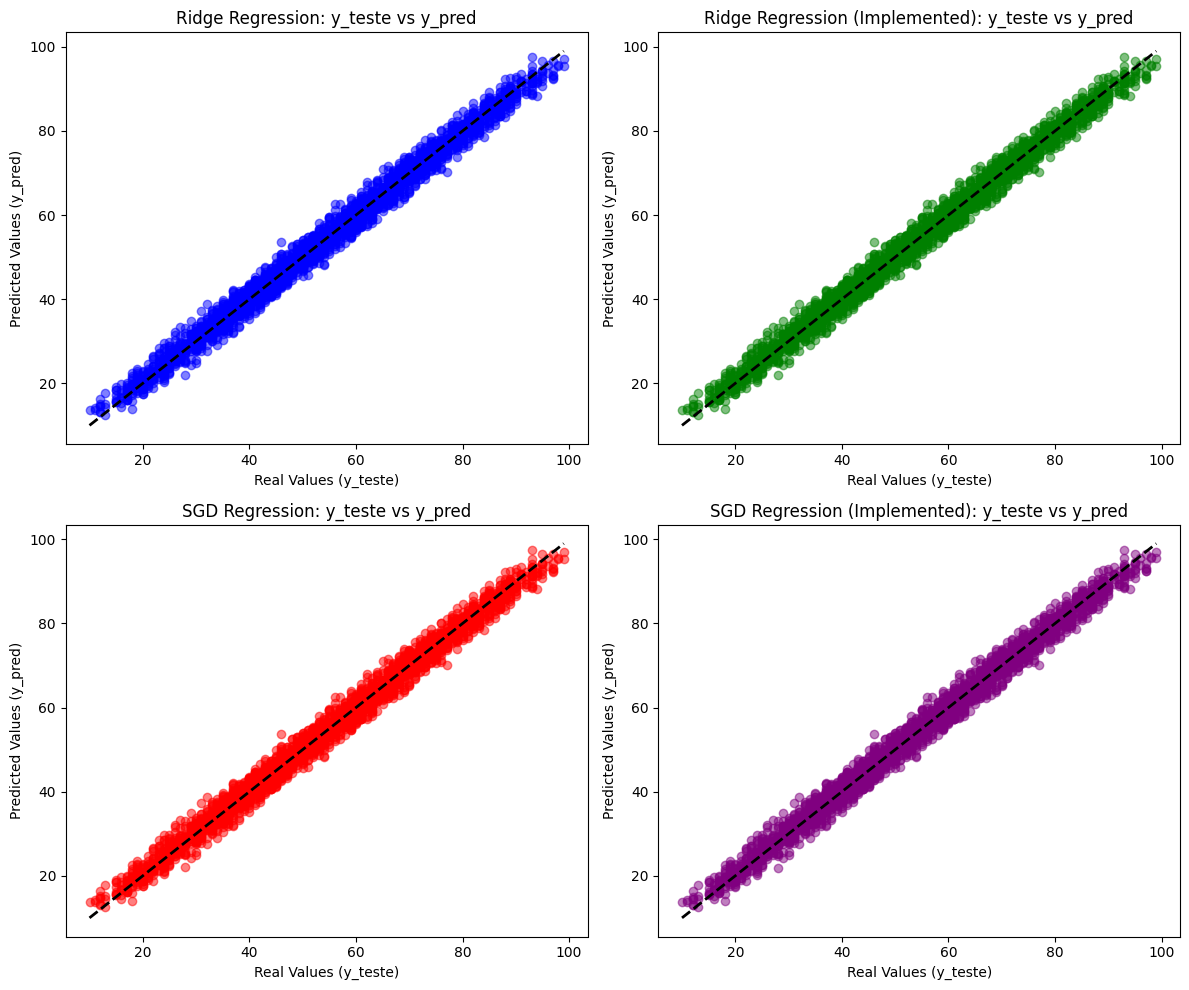

In [ ]:
plt.figure(figsize=(12, 10))

# Ridge
plt.subplot(2, 2, 1)
plt.scatter(y_teste, ridgePredictTeste, alpha=0.5, color='blue')
plt.plot([y_teste.min(), y_teste.max()], [y_teste.min(), y_teste.max()], 'k--', lw=2)
plt.xlabel("Real Values (y_teste)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("Ridge Regression: y_teste vs y_pred")

# Ridge (Implemented)
plt.subplot(2, 2, 2)
plt.scatter(y_teste, ridgeImplementadoPredictTeste, alpha=0.5, color='green')
plt.plot([y_teste.min(), y_teste.max()], [y_teste.min(), y_teste.max()], 'k--', lw=2)
plt.xlabel("Real Values (y_teste)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("Ridge Regression (Implemented): y_teste vs y_pred")

# SGD
plt.subplot(2, 2, 3)
plt.scatter(y_teste, gradientePredictTeste, alpha=0.5, color='red')
plt.plot([y_teste.min(), y_teste.max()], [y_teste.min(), y_teste.max()], 'k--', lw=2)
plt.xlabel("Real Values (y_teste)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("SGD Regression: y_teste vs y_pred")

# SGD (Implemented)
plt.subplot(2, 2, 4)
plt.scatter(y_teste, gradienteImplementadoPredictTeste, alpha=0.5, color='purple')
plt.plot([y_teste.min(), y_teste.max()], [y_teste.min(), y_teste.max()], 'k--', lw=2)
plt.xlabel("Real Values (y_teste)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("SGD Regression (Implemented): y_teste vs y_pred")

plt.tight_layout()
plt.show()